# **Script to compute carbon budget in the mesopelagic zone**
# Sources: Net POC fluxes + DCF
# With Net POC fluxes computed by taking into account ascending and descending fluxes
# Demands: PCD (Prokaryote Heterotrophic Demand) = PHP (Prokaryotic Heterotrophic Production) + PHR (Prokaryotic Heterotrophic Respiration)
# PCD, PHP, and PHR from Le Coq et al., 2026
# Uncertainties estimated from Monte Carlo analysis

# **Libraries**

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

In [51]:
# Import POC fluxes from APERO cruise
POC_fluxes_APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/mean_std_POC_fluxes_APERO_TZEX.csv')
POC_fluxes_APERO = POC_fluxes_APERO[['Site', 'Pressure [dbar]', 'asc_POC_fluxes_mgC_m2_d_alldredge_mean', 'asc_POC_fluxes_mgC_m2_d_alldredge_std', 'desc_POC_fluxes_mgC_m2_d_alldredge_mean', 'desc_POC_fluxes_mgC_m2_d_alldredge_std']]
POC_fluxes_APERO.head(3)

,Site,Pressure [dbar],asc_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_std
0,ST01_PSS1,25,-325.102652,153.935748,427.899337,243.872587
1,ST01_PSS1,50,-251.122890,35.046682,312.546317,42.602490
2,ST01_PSS1,75,-180.370261,29.978757,219.563675,34.947500


In [52]:
# Select upper and lower border of the mesopelagic zone
POC_fluxes_up_low = POC_fluxes_APERO[
    ((POC_fluxes_APERO['Pressure [dbar]'] >= 0) & (POC_fluxes_APERO['Pressure [dbar]'] <= 200)) |
    ((POC_fluxes_APERO['Pressure [dbar]'] >= 900) & (POC_fluxes_APERO['Pressure [dbar]'] <= 1100))
].copy()

In [54]:
POC_fluxes_up_low

,Site,Pressure [dbar],asc_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_std
0,ST01_PSS1,25,-325.102652,153.935748,427.899337,243.872587
1,ST01_PSS1,50,-251.122890,35.046682,312.546317,42.602490
2,ST01_PSS1,75,-180.370261,29.978757,219.563675,34.947500
3,ST01_PSS1,100,-130.598166,19.061434,158.766109,23.897356
4,ST01_PSS1,125,-113.347735,12.316286,136.640877,15.936711
...,...,...,...,...,...,...
205,ST42_PSS5,950,-43.845399,2.002334,60.679812,3.247273
206,ST42_PSS5,975,-42.975069,2.484870,58.463865,3.636994
207,ST42_PSS5,1000,-42.882519,1.743109,58.667218,3.273720
208,ST42_PSS5,1025,-42.398102,1.838787,58.244994,3.015247


In [55]:
# Assign depth layer 
POC_fluxes_up_low['Depth_m'] = POC_fluxes_up_low['Pressure [dbar]'].apply(
    lambda x: 100 if 0 <= x <= 200 else 1000
)
POC_fluxes_up_low.head(3)

,Site,Pressure [dbar],asc_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_std,Depth_m
0,ST01_PSS1,25,-325.102652,153.935748,427.899337,243.872587,100
1,ST01_PSS1,50,-251.122890,35.046682,312.546317,42.602490,100
2,ST01_PSS1,75,-180.370261,29.978757,219.563675,34.947500,100


In [56]:
# Compute average and std values in each layer 
POC_fluxes_up_low = (
    POC_fluxes_up_low.groupby(['Site', 'Depth_m'], as_index=False)
      .mean(numeric_only=True)
)
# Compute absolute ascending fluxes (for mean and std)
POC_fluxes_up_low['asc_POC_fluxes_mgC_m2_d_alldredge_mean'] = abs(POC_fluxes_up_low['asc_POC_fluxes_mgC_m2_d_alldredge_mean'])
POC_fluxes_up_low['asc_POC_fluxes_mgC_m2_d_alldredge_std'] = abs(POC_fluxes_up_low['asc_POC_fluxes_mgC_m2_d_alldredge_std'])
POC_fluxes_up_low.head(3)

,Site,Depth_m,Pressure [dbar],asc_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_std
0,ST01_PSS1,100,112.5,159.846377,34.413621,198.333577,49.115873
1,ST01_PSS1,1000,975.0,49.008252,2.388857,58.146684,3.017171
2,ST11_PSS2,100,112.5,258.461914,70.813362,423.427880,151.203977


In [57]:
# Pivot so that we have separate columns for 100m and 1000m
df_pivot = POC_fluxes_up_low.pivot(index='Site', columns='Depth_m', 
                         values=['asc_POC_fluxes_mgC_m2_d_alldredge_mean',
                                 'asc_POC_fluxes_mgC_m2_d_alldredge_std',
                                 'desc_POC_fluxes_mgC_m2_d_alldredge_mean',
                                 'desc_POC_fluxes_mgC_m2_d_alldredge_std'])

df_pivot.columns = [f"{flux}_{int(layer)}m" for flux, layer in df_pivot.columns]
df_pivot.reset_index()
df_pivot.head(3)

,asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,asc_POC_fluxes_mgC_m2_d_alldredge_std_100m,asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_std_100m,desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m
Site,,,,,,,,
ST01_PSS1,159.846377,49.008252,34.413621,2.388857,198.333577,58.146684,49.115873,3.017171
ST11_PSS2,258.461914,54.802095,70.813362,2.658043,423.427880,88.365439,151.203977,6.414543
ST25_PSS3,83.461559,38.516363,16.706497,2.215245,151.568723,48.833240,34.024047,3.231977


In [58]:
# Compute sources and sinks
df_pivot['sources'] = df_pivot['desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m'] + df_pivot['asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m']
df_pivot['sinks'] = df_pivot['desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m'] + df_pivot['asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m']

# Compute delta POC
df_pivot['delta_POC'] = df_pivot['sources'] - df_pivot['sinks']

# Keep only the delta column
delta_POC_df = df_pivot.reset_index()
delta_POC_df['Site'] = delta_POC_df['Site'].str.replace(r'^.*_', '', regex=True)
delta_POC_df

,Site,asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,asc_POC_fluxes_mgC_m2_d_alldredge_std_100m,asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_std_100m,desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,sources,sinks,delta_POC
0,PSS1,159.846377,49.008252,34.413621,2.388857,198.333577,58.146684,49.115873,3.017171,247.341829,217.993061,29.348768
1,PSS2,258.461914,54.802095,70.813362,2.658043,423.427880,88.365439,151.203977,6.414543,478.229976,346.827353,131.402622
2,PSS3,83.461559,38.516363,16.706497,2.215245,151.568723,48.833240,34.024047,3.231977,190.085086,132.294798,57.790287
3,PSS4,141.563236,40.505924,23.470579,1.957987,240.145820,50.710936,41.592364,4.157287,280.651745,192.274172,88.377573
4,PSS5,193.179668,43.524400,44.379798,1.903991,309.889347,59.954882,67.653013,3.311615,353.413748,253.134550,100.279198


In [59]:
# Import data from Le Coq et al., 2026
carbon_inputs = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/Carbon_inputs.csv', delimiter = ';')
carbon_inputs_pivot = carbon_inputs.pivot(
    index='Station',       # becomes the rows
    columns='Fraction',    # unique values become new columns
    values='Input'         # values to fill the new columns
).reset_index()

carbon_inputs_pivot = carbon_inputs_pivot.rename(columns={
    'Station': 'Site',
    'DCF_Free-living': 'DCF_free_living_int_mgC_m2_d',
    'DCF_attached-to-sinking-particles': 'desc_DCF_attached_part_int_mgC_m2_d'
})

carbon_inputs_pivot = carbon_inputs_pivot.drop('delta_POC', axis = 1)
carbon_inputs_pivot['DCF_free_living_int_mgC_m2_d_std'] = [0.95, np.nan, 1.41, 1.67, 3.43]
carbon_inputs_pivot['desc_DCF_attached_part_int_mgC_m2_d_std'] = [0.0007, 0.0006, 0.0007, 0.002, np.nan]
carbon_inputs_pivot

Fraction,Site,DCF_free_living_int_mgC_m2_d,desc_DCF_attached_part_int_mgC_m2_d,DCF_free_living_int_mgC_m2_d_std,desc_DCF_attached_part_int_mgC_m2_d_std
0,PSS1,7.02,0.052783,0.95,0.0007
1,PSS2,NaN,0.055835,NaN,0.0006
2,PSS3,31.85,0.050379,1.41,0.0007
3,PSS4,10.48,0.157460,1.67,0.0020
4,PSS5,20.69,NaN,3.43,NaN


In [60]:
PCD_df = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/Carbon_budget/PCD.csv', delimiter = ';')
PCD_df_pivot = PCD_df.pivot(
    index='Station',       # becomes the rows
    columns='Fraction',    # unique values become new columns
    values='PCD'         # values to fill the new columns
).reset_index()

PCD_df_pivot = PCD_df_pivot.rename(columns={
    'Station': 'Site',
    'Attached_to_part': 'desc_PCD_attached_part_int_mgC_m2_d',
    'Free_living': 'PCD_free_living_int_mgC_m2_d'
})
PGE = 0.087
PCD_df_pivot['desc_PCD_attached_part_int_mgC_m2_d_std'] = [0.331, 0.346, 4.154, 1.962, 2.192]
PCD_df_pivot['PCD_free_living_int_mgC_m2_d_std'] = [0.52/PGE, 0.36/PGE, 0.49/PGE, 0.44/PGE, 0.38/PGE]
PCD_df_pivot

Fraction,Site,desc_PCD_attached_part_int_mgC_m2_d,PCD_free_living_int_mgC_m2_d,desc_PCD_attached_part_int_mgC_m2_d_std,PCD_free_living_int_mgC_m2_d_std
0,PSS1,1.919851,73.908046,0.331,5.977011
1,PSS2,7.450369,45.172414,0.346,4.137931
2,PSS3,14.906541,62.758621,4.154,5.632184
3,PSS4,12.398127,67.701149,1.962,5.057471
4,PSS5,21.338442,45.287356,2.192,4.367816


In [61]:
final_df = pd.merge(delta_POC_df, carbon_inputs_pivot, on = 'Site')
final_df = pd.merge(final_df, PCD_df_pivot, on = 'Site')
final_df

,Site,asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,asc_POC_fluxes_mgC_m2_d_alldredge_std_100m,asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_std_100m,desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,sources,sinks,delta_POC,DCF_free_living_int_mgC_m2_d,desc_DCF_attached_part_int_mgC_m2_d,DCF_free_living_int_mgC_m2_d_std,desc_DCF_attached_part_int_mgC_m2_d_std,desc_PCD_attached_part_int_mgC_m2_d,PCD_free_living_int_mgC_m2_d,desc_PCD_attached_part_int_mgC_m2_d_std,PCD_free_living_int_mgC_m2_d_std
0,PSS1,159.846377,49.008252,34.413621,2.388857,198.333577,58.146684,49.115873,3.017171,247.341829,217.993061,29.348768,7.02,0.052783,0.95,0.0007,1.919851,73.908046,0.331,5.977011
1,PSS2,258.461914,54.802095,70.813362,2.658043,423.427880,88.365439,151.203977,6.414543,478.229976,346.827353,131.402622,NaN,0.055835,NaN,0.0006,7.450369,45.172414,0.346,4.137931
2,PSS3,83.461559,38.516363,16.706497,2.215245,151.568723,48.833240,34.024047,3.231977,190.085086,132.294798,57.790287,31.85,0.050379,1.41,0.0007,14.906541,62.758621,4.154,5.632184
3,PSS4,141.563236,40.505924,23.470579,1.957987,240.145820,50.710936,41.592364,4.157287,280.651745,192.274172,88.377573,10.48,0.157460,1.67,0.0020,12.398127,67.701149,1.962,5.057471
4,PSS5,193.179668,43.524400,44.379798,1.903991,309.889347,59.954882,67.653013,3.311615,353.413748,253.134550,100.279198,20.69,NaN,3.43,NaN,21.338442,45.287356,2.192,4.367816


In [62]:
# Compute ascending fractions
final_df['asc_DCF_attached_part_int_mgC_m2_d'] = (final_df['desc_DCF_attached_part_int_mgC_m2_d'] * 39) / 61
final_df['asc_PCD_attached_part_int_mgC_m2_d'] = (final_df['desc_PCD_attached_part_int_mgC_m2_d'] * 39) / 61
final_df

,Site,asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,asc_POC_fluxes_mgC_m2_d_alldredge_std_100m,asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_std_100m,desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,sources,...,DCF_free_living_int_mgC_m2_d,desc_DCF_attached_part_int_mgC_m2_d,DCF_free_living_int_mgC_m2_d_std,desc_DCF_attached_part_int_mgC_m2_d_std,desc_PCD_attached_part_int_mgC_m2_d,PCD_free_living_int_mgC_m2_d,desc_PCD_attached_part_int_mgC_m2_d_std,PCD_free_living_int_mgC_m2_d_std,asc_DCF_attached_part_int_mgC_m2_d,asc_PCD_attached_part_int_mgC_m2_d
0,PSS1,159.846377,49.008252,34.413621,2.388857,198.333577,58.146684,49.115873,3.017171,247.341829,...,7.02,0.052783,0.95,0.0007,1.919851,73.908046,0.331,5.977011,0.033747,1.227446
1,PSS2,258.461914,54.802095,70.813362,2.658043,423.427880,88.365439,151.203977,6.414543,478.229976,...,NaN,0.055835,NaN,0.0006,7.450369,45.172414,0.346,4.137931,0.035698,4.763351
2,PSS3,83.461559,38.516363,16.706497,2.215245,151.568723,48.833240,34.024047,3.231977,190.085086,...,31.85,0.050379,1.41,0.0007,14.906541,62.758621,4.154,5.632184,0.032210,9.530411
3,PSS4,141.563236,40.505924,23.470579,1.957987,240.145820,50.710936,41.592364,4.157287,280.651745,...,10.48,0.157460,1.67,0.0020,12.398127,67.701149,1.962,5.057471,0.100671,7.926671
4,PSS5,193.179668,43.524400,44.379798,1.903991,309.889347,59.954882,67.653013,3.311615,353.413748,...,20.69,NaN,3.43,NaN,21.338442,45.287356,2.192,4.367816,NaN,13.642610


In [63]:
# Total Supply and Demand
final_df['tot_POC_supply_mgC_m2_d'] = (
    final_df['delta_POC'].fillna(0) + 
    final_df['DCF_free_living_int_mgC_m2_d'].fillna(0) + 
    final_df['desc_DCF_attached_part_int_mgC_m2_d'].fillna(0) +  
    final_df['asc_DCF_attached_part_int_mgC_m2_d'].fillna(0)
)

final_df['tot_POC_demand_mgC_m2_d'] = (
    final_df['PCD_free_living_int_mgC_m2_d'].fillna(0) + 
    final_df['desc_PCD_attached_part_int_mgC_m2_d'].fillna(0) +
    final_df['asc_PCD_attached_part_int_mgC_m2_d'].fillna(0)
)

final_df['carbon_budget'] = final_df['tot_POC_supply_mgC_m2_d'] - final_df['tot_POC_demand_mgC_m2_d']
final_df

,Site,asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,asc_POC_fluxes_mgC_m2_d_alldredge_std_100m,asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m,desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m,desc_POC_fluxes_mgC_m2_d_alldredge_std_100m,desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m,sources,...,desc_DCF_attached_part_int_mgC_m2_d_std,desc_PCD_attached_part_int_mgC_m2_d,PCD_free_living_int_mgC_m2_d,desc_PCD_attached_part_int_mgC_m2_d_std,PCD_free_living_int_mgC_m2_d_std,asc_DCF_attached_part_int_mgC_m2_d,asc_PCD_attached_part_int_mgC_m2_d,tot_POC_supply_mgC_m2_d,tot_POC_demand_mgC_m2_d,carbon_budget
0,PSS1,159.846377,49.008252,34.413621,2.388857,198.333577,58.146684,49.115873,3.017171,247.341829,...,0.0007,1.919851,73.908046,0.331,5.977011,0.033747,1.227446,36.455298,77.055343,-40.600046
1,PSS2,258.461914,54.802095,70.813362,2.658043,423.427880,88.365439,151.203977,6.414543,478.229976,...,0.0006,7.450369,45.172414,0.346,4.137931,0.035698,4.763351,131.494154,57.386134,74.108020
2,PSS3,83.461559,38.516363,16.706497,2.215245,151.568723,48.833240,34.024047,3.231977,190.085086,...,0.0007,14.906541,62.758621,4.154,5.632184,0.032210,9.530411,89.722877,87.195573,2.527304
3,PSS4,141.563236,40.505924,23.470579,1.957987,240.145820,50.710936,41.592364,4.157287,280.651745,...,0.0020,12.398127,67.701149,1.962,5.057471,0.100671,7.926671,99.115704,88.025948,11.089756
4,PSS5,193.179668,43.524400,44.379798,1.903991,309.889347,59.954882,67.653013,3.311615,353.413748,...,NaN,21.338442,45.287356,2.192,4.367816,NaN,13.642610,120.969198,80.268409,40.700789


In [64]:
# =============================================================================
# === MONTE CARLO ERROR PROPAGATION BLOCK ===
# =============================================================================
n_simulations = 10000

# Constants for metabolic uncertainties
#rel_err_DCF_free = 0.2
#rel_err_DCF_desc = 0.2
#rel_err_PCD_free = 0.2
#rel_err_PCD_desc = 0.2

std_supply_list = []
std_demand_list = []

for idx, row in final_df.iterrows():
    # 1. Pull means (fill with 0 if missing)
    mu_d100 = row['desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m'] if pd.notna(row['desc_POC_fluxes_mgC_m2_d_alldredge_mean_100m']) else 0
    mu_a1000 = row['asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m'] if pd.notna(row['asc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m']) else 0
    mu_d1000 = row['desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m'] if pd.notna(row['desc_POC_fluxes_mgC_m2_d_alldredge_mean_1000m']) else 0
    mu_a100 = row['asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m'] if pd.notna(row['asc_POC_fluxes_mgC_m2_d_alldredge_mean_100m']) else 0
    
    mu_dcf_free = row['DCF_free_living_int_mgC_m2_d'] if pd.notna(row['DCF_free_living_int_mgC_m2_d']) else 0
    mu_dcf_desc = row['desc_DCF_attached_part_int_mgC_m2_d'] if pd.notna(row['desc_DCF_attached_part_int_mgC_m2_d']) else 0
    
    mu_pcd_free = row['PCD_free_living_int_mgC_m2_d'] if pd.notna(row['PCD_free_living_int_mgC_m2_d']) else 0
    mu_pcd_desc = row['desc_PCD_attached_part_int_mgC_m2_d'] if pd.notna(row['desc_PCD_attached_part_int_mgC_m2_d']) else 0

    # 1.5 Pull Standard Deviations directly (DO NOT divide by mu)
    std_d100 = row['desc_POC_fluxes_mgC_m2_d_alldredge_std_100m'] if pd.notna(row['desc_POC_fluxes_mgC_m2_d_alldredge_std_100m']) else 0
    std_a1000 = row['asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m'] if pd.notna(row['asc_POC_fluxes_mgC_m2_d_alldredge_std_1000m']) else 0
    std_d1000 = row['desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m'] if pd.notna(row['desc_POC_fluxes_mgC_m2_d_alldredge_std_1000m']) else 0
    std_a100 = row['asc_POC_fluxes_mgC_m2_d_alldredge_std_100m'] if pd.notna(row['asc_POC_fluxes_mgC_m2_d_alldredge_std_100m']) else 0
    std_d_PCD = row['desc_PCD_attached_part_int_mgC_m2_d_std'] if pd.notna(row['desc_PCD_attached_part_int_mgC_m2_d_std']) else 0
    std_d_DCF = row['desc_DCF_attached_part_int_mgC_m2_d_std'] if pd.notna(row['desc_DCF_attached_part_int_mgC_m2_d_std']) else 0
    
    std_free_PCD = row['PCD_free_living_int_mgC_m2_d_std'] if pd.notna(row['PCD_free_living_int_mgC_m2_d_std']) else 0
    std_free_DCF = row['DCF_free_living_int_mgC_m2_d_std'] if pd.notna(row['DCF_free_living_int_mgC_m2_d_std']) else 0
    
    print(' ')

    print('Site', row['Site'])

    print('mu_d100:', mu_d100)

    print('std_d100:', std_d100)
    print('std_d100_prop:', (std_d100*100)/mu_d100)


    print(' ')

    print('mu_d1000:', mu_d1000)

    print('std_d1000:', std_d1000)
    print('std_d1000_prop:', (std_d1000*100)/mu_d1000)



    print(' ')

    print('mu_a100:', mu_a100)

    print('std_a100:', std_a100)
    print('std_a100_prop:', (std_a100*100)/mu_a100)


    print(' ')

    print('mu_a1000:', mu_a1000)

    print('std_a1000:', std_a1000)
    print('std_a1000_prop:', (std_a1000*100)/mu_a1000)

    print(' ')

    print('mu_PCD_desc:', mu_pcd_desc)

    print('std_PCD_desc:', std_d_PCD)
    print('std_PCD_desc_prop:', (std_d_PCD*100)/mu_pcd_desc)

    print(' ')

    print('mu_PCD_free:', mu_pcd_free)

    print('std_PCD_free:', std_free_PCD)
    print('std_PCD_desc_prop:', (std_free_PCD*100)/mu_pcd_free)

    print(' ')

    print('mu_DCF_free:', mu_dcf_free)

    print('std_DCF_free:', std_free_DCF)
    if mu_dcf_free == 0:
        print('std_PCD_desc_prop: nan')
    else:
        print('std_PCD_desc_prop:', (std_free_DCF*100)/mu_dcf_free)
    
    print('-------')
    
    # 2. Simulate normal distributions using absolute std
    sim_d100 = np.random.normal(mu_d100, std_d100, n_simulations)
    sim_a1000 = np.random.normal(mu_a1000, std_a1000, n_simulations)
    sim_d1000 = np.random.normal(mu_d1000, std_d1000, n_simulations)
    sim_a100 = np.random.normal(mu_a100, std_a100, n_simulations)
    
    sim_dcf_free = np.random.normal(mu_dcf_free, std_free_DCF, n_simulations)
    sim_dcf_desc = np.random.normal(mu_dcf_desc, std_d_DCF, n_simulations)
    sim_pcd_free = np.random.normal(mu_pcd_free, std_free_PCD, n_simulations)
    sim_pcd_desc = np.random.normal(mu_pcd_desc, std_d_PCD, n_simulations)

    # 3. Calculate dependent variables in simulation
    sim_asc_dcf = (sim_dcf_desc * 39) / 61
    sim_asc_pcd = (sim_pcd_desc * 39) / 61
    
    # 4. Compute Totals per simulation
    sim_delta_poc = (sim_d100 + sim_a1000) - (sim_d1000 + sim_a100)
    sim_supply = sim_delta_poc + sim_dcf_free + sim_dcf_desc + sim_asc_dcf
    sim_demand = sim_pcd_free + sim_pcd_desc + sim_asc_pcd
    
    # 5. Extract standard deviation
    std_supply_list.append(np.std(sim_supply))
    std_demand_list.append(np.std(sim_demand))

final_df['std_supply'] = std_supply_list
final_df['std_demand'] = std_demand_list

 
Site PSS1
mu_d100: 198.33357717865698
std_d100: 49.11587331821613
std_d100_prop: 24.76427542774213
 
mu_d1000: 58.14668429163942
std_d1000: 3.0171708378375466
std_d1000_prop: 5.18889576352227
 
mu_a100: 159.84637717742658
std_a100: 34.4136208275035
std_a100_prop: 21.529184104876524
 
mu_a1000: 49.00825199948826
std_a1000: 2.388857367943662
std_a1000_prop: 4.874398229850366
 
mu_PCD_desc: 1.919851304
std_PCD_desc: 0.331
std_PCD_desc_prop: 17.24091857063947
 
mu_PCD_free: 73.90804598
std_PCD_free: 5.977011494252874
std_PCD_desc_prop: 8.087091757060243
 
mu_DCF_free: 7.02
std_DCF_free: 0.95
std_PCD_desc_prop: 13.532763532763534
-------
 
Site PSS2
mu_d100: 423.42788036449167
std_d100: 151.20397691857295
std_d100_prop: 35.70949952289745
 
mu_d1000: 88.36543897130734
std_d1000: 6.414543329725807
std_d1000_prop: 7.259108769672539
 
mu_a100: 258.461914475503
std_a100: 70.8133622674446
std_a100_prop: 27.397987208732943
 
mu_a1000: 54.802095227853066
std_a1000: 2.658043027016762
std_a1000_pro

In [65]:
final_df[['Site', 'std_supply', 'std_demand']]

,Site,std_supply,std_demand
0,PSS1,59.797675,5.909296
1,PSS2,166.615666,4.124200
2,PSS3,38.105126,8.746105
3,PSS4,48.084999,5.944484
4,PSS5,81.077935,5.622118


# Generate figure

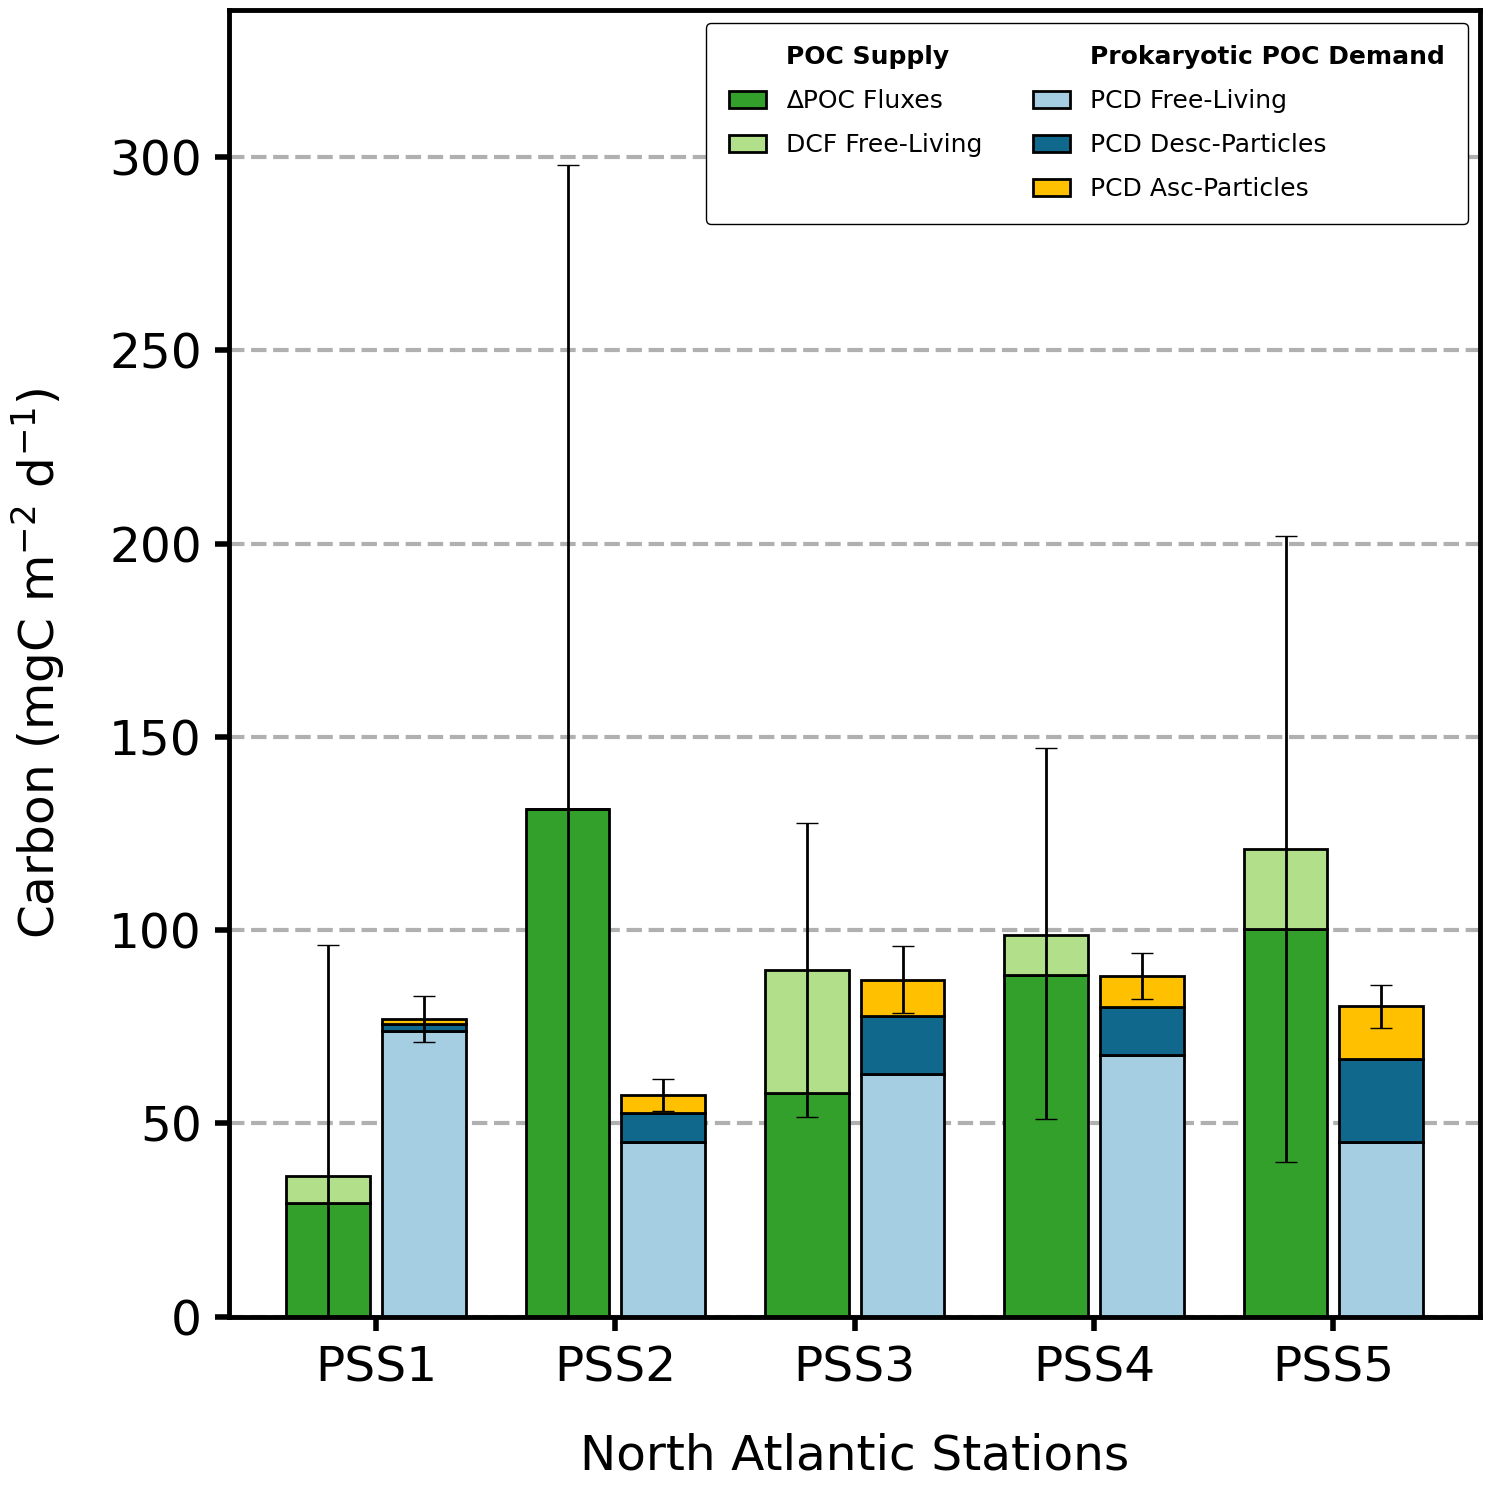

In [67]:
# Setup plotting variables
sites = final_df['Site']
x = np.arange(len(sites))
width = 0.35
gap = 0.05  
linewidth = 2
size = 35
l, w, pad = 10, 4, 10

# POC supply arrays
delta_POC = final_df['delta_POC'].fillna(0)
DCF_free_leaving_int = final_df['DCF_free_living_int_mgC_m2_d'].fillna(0)
desc_DCF_attached_part_int = final_df['desc_DCF_attached_part_int_mgC_m2_d'].fillna(0)
asc_DCF_attached_part_int = final_df['asc_DCF_attached_part_int_mgC_m2_d'].fillna(0)

# POC demand arrays
PCD_free_living_int = final_df['PCD_free_living_int_mgC_m2_d'].fillna(0)
desc_PCD_attached_part_int = final_df['desc_PCD_attached_part_int_mgC_m2_d'].fillna(0)
asc_PCD_attached_part_int = final_df['asc_PCD_attached_part_int_mgC_m2_d'].fillna(0)

carbon_budget = final_df['carbon_budget']
std_supply = final_df['std_supply']
std_demand = final_df['std_demand']

# Figure
fig, ax = plt.subplots(figsize=(15, 15))
ax.grid(True, which="both", axis='y', ls="--", linewidth=3, zorder = 1, alpha=1)

# Plot supply stacked bar 
p1 = ax.bar(x - width/2 - gap/2, delta_POC, width, label='', color='#33a02c', linewidth = linewidth, edgecolor='black', zorder = 2)
p2 = ax.bar(x - width/2 - gap/2, DCF_free_leaving_int, width, bottom=delta_POC, label='', color='#b2df8a', linewidth = linewidth, edgecolor='black', zorder = 2)
p3 = ax.bar(x - width/2 - gap/2, desc_DCF_attached_part_int, width, bottom=delta_POC + DCF_free_leaving_int, label='', color='white', linewidth = linewidth, edgecolor='white', zorder = 1)

# Plot demand stacked bar 
p5 = ax.bar(x + width/2 + gap/2, PCD_free_living_int, width, label='', color='#a6cee3', linewidth = linewidth, edgecolor='black', zorder = 2)
p6 = ax.bar(x + width/2 + gap/2, desc_PCD_attached_part_int, width, bottom = PCD_free_living_int, label='', color='#10698D', linewidth = linewidth, edgecolor='black', zorder = 2)
p7 = ax.bar(x + width/2 + gap/2, asc_PCD_attached_part_int, width, bottom = PCD_free_living_int + desc_PCD_attached_part_int, label='', color='#FFC000', linewidth = linewidth, edgecolor='black', zorder = 2)

# === ADD ERROR BARS ===
supply_tops = delta_POC + DCF_free_leaving_int + desc_DCF_attached_part_int + asc_DCF_attached_part_int
demand_tops = PCD_free_living_int + desc_PCD_attached_part_int + asc_PCD_attached_part_int

ax.errorbar(x - width/2 - gap/2, supply_tops, yerr=std_supply, fmt='none', ecolor='black', capsize=8, elinewidth=2, zorder=3)
ax.errorbar(x + width/2 + gap/2, demand_tops, yerr=std_demand, fmt='none', ecolor='black', capsize=8, elinewidth=2, zorder=3)

# Annotate carbon_budget above each pair of bars (Dynamically adjusted for error bars)
'''
for i, cb in enumerate(carbon_budget):
    # Find the maximum height between the supply and demand bars directly
    y = max(supply_tops[i], demand_tops[i]) + 15 
    
    # Place the text
    ax.text(x[i], y, f"{cb:.1f}", ha='center', va='bottom', color='black', 
            fontsize=size/1.5, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))
'''

# X-axis
ax.set_xticks(range(len(sites)))
ax.set_xticklabels(sites, rotation=0)
ax.tick_params(axis='y', labelsize=size, pad=pad, length=l, width=w)
ax.tick_params(axis='x', labelsize=size, pad=pad, length=l, width=w)
ax.set_xlabel('North Atlantic Stations', size=size, labelpad=30)

# Adjust y-limit
ax.set_ylim(0, max(max(supply_tops + std_supply), max(demand_tops + std_demand)) + 40)

# Labels
ax.set_ylabel('Carbon (mgC m$^{-2}$ d$^{-1}$)', size=size, labelpad=30)

# --- Legend setup ---

handles_supply = [p1[0], p2[0], p3[0]]
labels_supply = ['∆POC Fluxes', 'DCF Free-Living', '']

handles_demand = [p5[0], p6[0], p7[0]]
labels_demand = ['PCD Free-Living', 'PCD Desc-Particles', 'PCD Asc-Particles']

header_supply = Patch(facecolor='none', edgecolor='none')
header_demand = Patch(facecolor='none', edgecolor='none')

handles = [header_supply] + handles_supply + [header_demand] + handles_demand
labels  = ['POC Supply']   + labels_supply  + ['Prokaryotic POC Demand']   + labels_demand

legend_fontsize = 18
legend = ax.legend(
    handles, labels, ncol=2, fontsize=legend_fontsize, labelspacing=0.8,
    borderpad=0.9, frameon=True, loc='upper right', edgecolor='black',
    fancybox=True, framealpha=1, columnspacing=2.0, handlelength=1.5, handletextpad=0.8
)

for text, handle in zip(legend.get_texts(), handles):
    if isinstance(handle, Patch) and handle.get_facecolor() == (0.0, 0.0, 0.0, 0.0):
        text.set_weight('bold')

for spine in ax.spines.values():
    spine.set_linewidth(3.5)

plt.tight_layout()
#plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_5/Figure_5.png', dpi = 300)
plt.show()